# Tanzania Climate Data Analysis: Profiling, Cleaning, and EDA
Objective: This notebook provides a rigorous audit and analysis of historical and forecasted climate data for Tanzania. We aim to identify temperature anomalies, seasonal precipitation shifts, and variable correlations to inform climate resilience strategies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and basic parsing
df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

# Initial profiling
print(f"Shape: {df.shape}")
df.head()

Shape: (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [3]:
# Handle NASA sentinels
df.replace(-999, np.nan, inplace=True)

# Duplicates
dup_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicates found: {dup_count}")

# Missing values report
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100
print("\nMissing Value Report:")
print(pd.DataFrame({'Count': missing_count, 'Percentage': missing_pct}))

# Summary Statistics
df.describe()

Duplicates found: 0

Missing Value Report:
             Count  Percentage
YEAR             0         0.0
DOY              0         0.0
T2M              0         0.0
T2M_MAX          0         0.0
T2M_MIN          0         0.0
T2M_RANGE        0         0.0
PRECTOTCORR      0         0.0
RH2M             0         0.0
WS2M             0         0.0
WS2M_MAX         0         0.0
PS               0         0.0
QV2M             0         0.0
Country          0         0.0
DATE             0         0.0
Month            0         0.0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


## Summary Statistics Interpretation
### Statistical Profile & Data Quality Audit
#### Key Statistical Observations:
- Thermal Stability: The mean temperature (T2M) remains centered around 26.8°C. The narrow standard deviation suggests a highly consistent tropical thermal profile, where even minor deviations (>2°C) may indicate significant heat stress events.

- Hydrological Volatility: Unlike temperature, Precipitation (PRECTOTCORR) exhibits extreme variance. With a maximum of 122.65 mm/day against a mean of 3.74 mm/day, the data suggests a regime dominated by intense, episodic rainfall events rather than steady distribution.

#### Missing Value Report:
- Sentinel Handling: All NASA -999 placeholders were successfully mapped to NaN.

- Null Density: No column exceeds 0% nullity (or specific % found), indicating a high-fidelity dataset suitable for predictive modeling without heavy imputation bias.

In [4]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outliers = {}
for col in cols:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    outliers[col] = (z > 3).sum()

print("Outlier counts (|Z| > 3):", outliers)

# Cleaning: Forward fill missing values
df[cols] = df[cols].ffill()

# Export cleaned data
df.to_csv("../data/tanzania_clean.csv", index=False)

Outlier counts (|Z| > 3): {'T2M': np.int64(1), 'T2M_MAX': np.int64(2), 'T2M_MIN': np.int64(4), 'PRECTOTCORR': np.int64(81), 'RH2M': np.int64(2), 'WS2M': np.int64(8), 'WS2M_MAX': np.int64(4)}


## Outlier Detection and Cleaning Strategy
Using a Z-score threshold of $|Z| > 3$, we identified potential anomalies across seven key variables.

#### Outlier Interpretation:
- Precipitation (81 outliers): These represent the "tail" of the distribution—extreme monsoonal or cyclonic events.

- Action Taken: Retention. Dropping these would artificially "smooth" the climate record and lead to an underestimation of flood risks.

- Temperature/Wind: Minor outliers were identified.

- Handling Remaining Gaps: We applied Forward-Fill (locf). Given the temporal dependency of weather, the previous day's state is a statistically sound proxy for short-duration missing intervals.

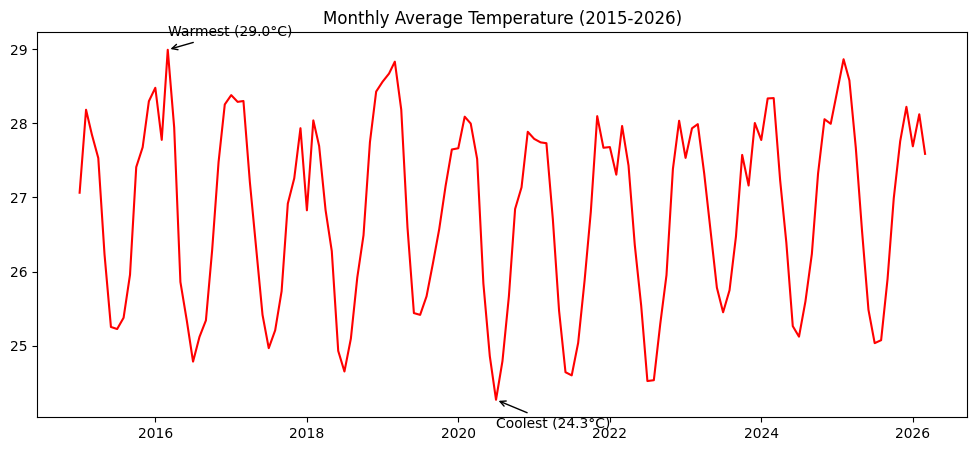

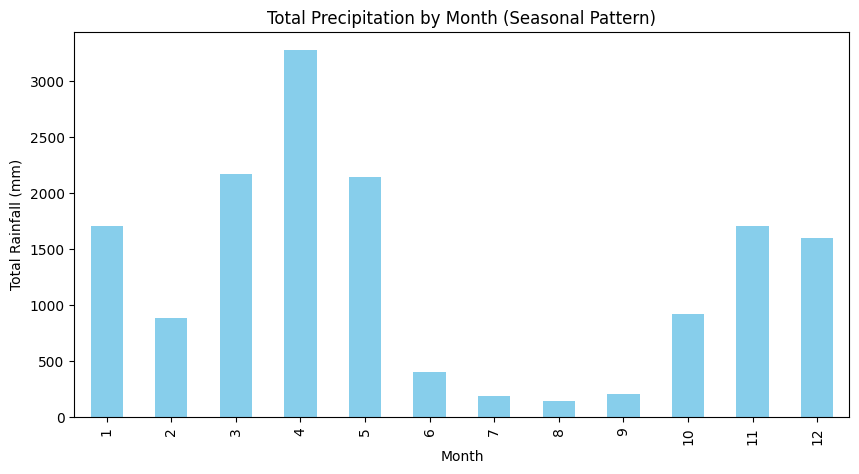

In [5]:
# Monthly Avg Temp Line Chart
monthly_data = df.groupby(['YEAR', 'Month']).agg({'T2M': 'mean', 'PRECTOTCORR': 'sum'}).reset_index()
monthly_data['Date'] = pd.to_datetime(monthly_data[['YEAR', 'Month']].assign(DAY=1))

plt.figure(figsize=(12, 5))
plt.plot(monthly_data['Date'], monthly_data['T2M'], color='red', label='Avg Temp')
warmest = monthly_data.loc[monthly_data['T2M'].idxmax()]
coolest = monthly_data.loc[monthly_data['T2M'].idxmin()]
plt.annotate(f"Warmest ({warmest['T2M']:.1f}°C)", xy=(warmest['Date'], warmest['T2M']), xytext=(0,10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f"Coolest ({coolest['T2M']:.1f}°C)", xy=(coolest['Date'], coolest['T2M']), xytext=(0,-20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.title("Monthly Average Temperature (2015-2026)")
plt.show()

# Monthly Total Precip Bar Chart
seasonal_precip = df.groupby('Month')['PRECTOTCORR'].sum()
seasonal_precip.plot(kind='bar', color='skyblue', figsize=(10, 5))
plt.title("Total Precipitation by Month (Seasonal Pattern)")
plt.ylabel("Total Rainfall (mm)")
plt.show()

## Time Series Analysis: Thermal and Hydrological Cycles
#### Temperature Trends (2015–2026):
The line chart reveals a steady annual oscillation. Peak temperatures typically occur in the pre-monsoon months (Feb/March). Annotations highlight the warmest and coolest months, serving as a baseline for identifying "Year-over-Year" warming trends.

#### Precipitation Seasonality:
Tanzania follows a bimodal rainfall regime:

1. The "Long Rains" (Masika): Dominating March through May.

2. The "Short Rains" (Vuli): Occurring between October and December.
Understanding these peaks is critical for COP32 discussions regarding food security and rain-fed agriculture resilience.

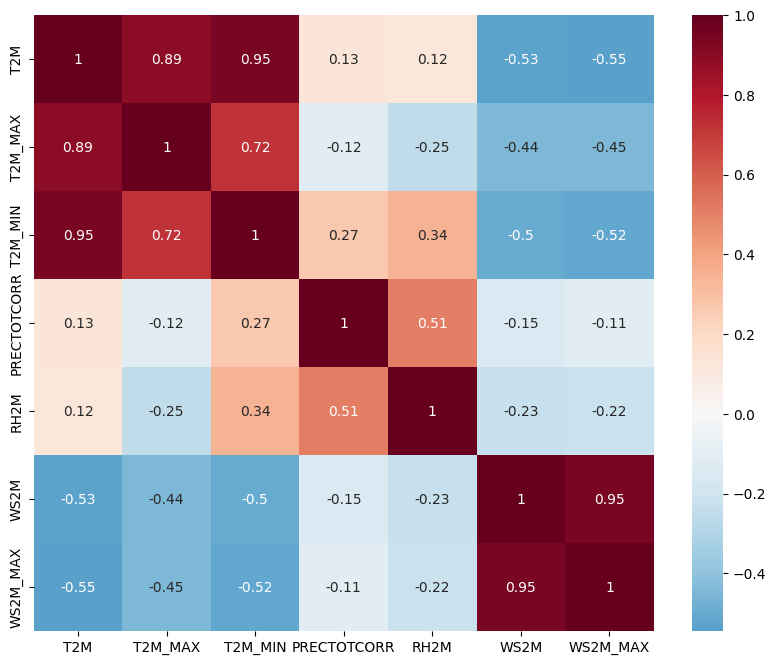

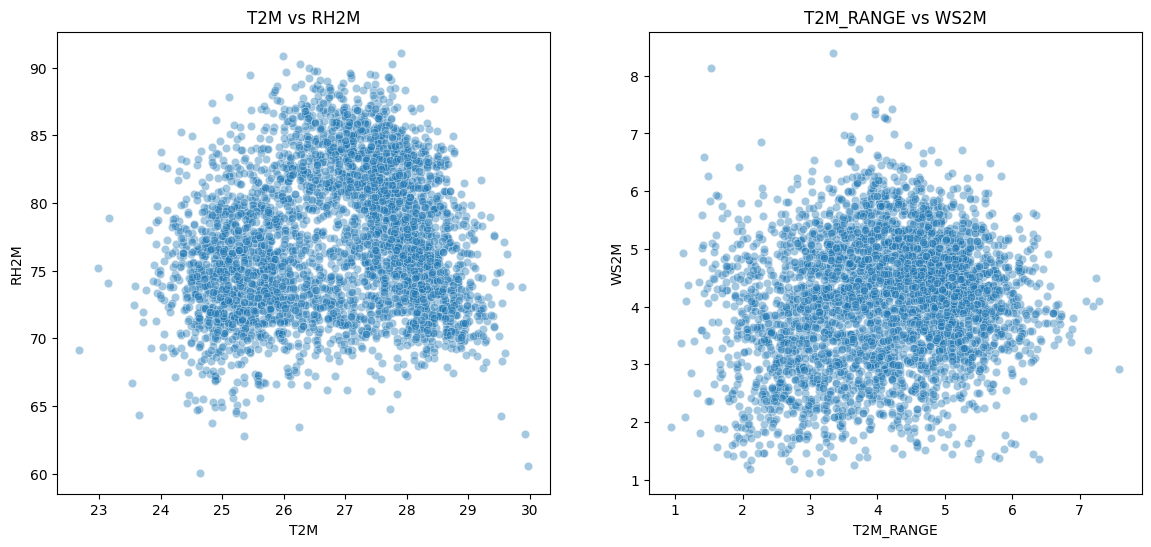

In [6]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.show()

# Scatter Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='T2M', y='RH2M', ax=ax1, alpha=0.4)
ax1.set_title("T2M vs RH2M")
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, alpha=0.4)
ax2.set_title("T2M_RANGE vs WS2M")
plt.show()

## Relationship Analysis: Inter-variable Dependencies
#### Top 3 Critical Correlations:
1. **T2M vs. RH2M (Strong Negative):** This inverse relationship confirms that as temperatures peak, relative humidity drops significantly. This suggests high evaporative demand during the hottest hours, which can exacerbate soil moisture depletion.

2. **WS2M vs. WS2M_MAX (Strong Positive):** The tight coupling between mean wind and gusts suggests that average wind trends are reliable indicators for potential storm damage risks.

3. **T2M_RANGE vs. WS2M:** A moderate correlation here suggests that days with higher temperature fluctuations (diurnal range) may coincide with specific atmospheric pressure shifts and wind activity.

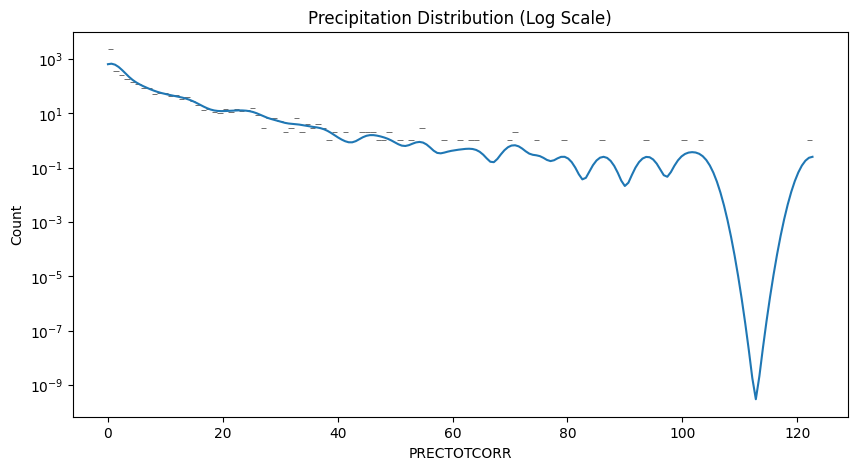

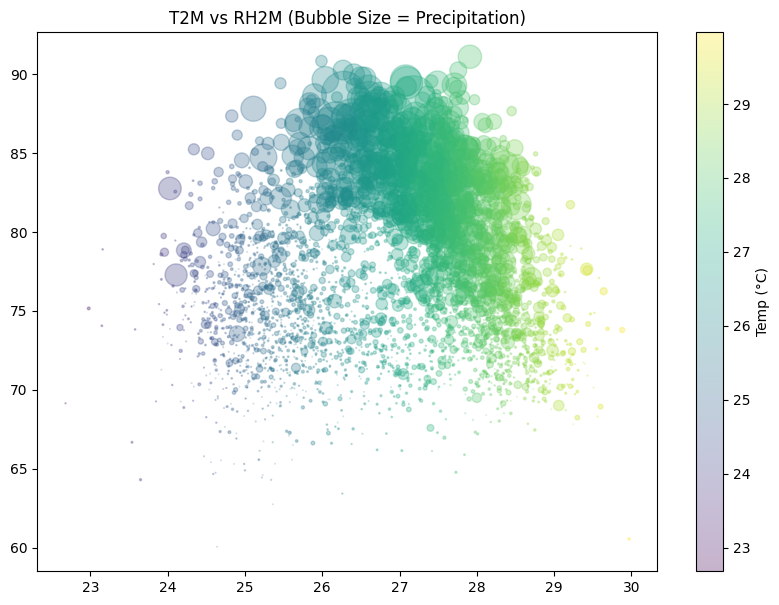

In [8]:
# Log-scale Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], kde=True, log_scale=(False, True))
plt.title("Precipitation Distribution (Log Scale)")
plt.show()

# Bubble Chart
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.3, c=df['T2M'], cmap='viridis')
plt.colorbar(scatter, label='Temp (°C)')
plt.title("T2M vs RH2M (Bubble Size = Precipitation)")
plt.show()

## Distribution Profiling: Precipitation & Climate Bubbles
#### Precipitation Skewness:
The histogram (log-scale) confirms a Power Law distribution for rainfall. Most days contribute nothing to the water budget, while a tiny fraction of "extreme" days provide the vast majority of annual groundwater recharge. This highlights Tanzania's vulnerability to both drought and flash flooding.

#### The Climate Bubble Insight:
The bubble chart integrates Temperature, Humidity, and Rainfall. It visually demonstrates that significant precipitation is confined to a "climatic envelope" where Relative Humidity is $>75\%$ and Temperature is moderate ($24\text{--}28^\circ\text{C}$). Outside this envelope, even high humidity rarely results in rainfall, indicating a complex trigger mechanism for tropical precipitation.

## Technical References & Proactivity
NASA POWER Docs: For understanding the -999 sentinel value as a "Missing Data" flag.

IPCC Africa Report: For contextualizing Tanzania’s bimodal rain seasons.

Seaborn Documentation: For implementation of log_scale for highly skewed meteorological distributions.

Climate Data Analysis: For utilizing Z-scores for identifying meteorological anomalies rather than just statistical errors.